In [ ]:
# Starter code
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Define transformations
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the Fashion MNIST dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Classes in Fashion MNIST
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

# TODO: Build your CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # TODO: Define your model architecture here

    def forward(self, x):
        # TODO: Define the forward pass here
        return x

# TODO: Train and evaluate your model

# TODO: Visualize results

100%|██████████| 26421880/26421880 [00:08<00:00, 3085906.03it/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 141322.88it/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 2626071.00it/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 2829176.75it/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [7]:
# Build CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Define model architecture 
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Define the forward pass 
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        x = x.view(-1, 64 * 7 * 7)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [8]:
# Train and evaluate model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch 1/10, Loss: 0.5764, Accuracy: 85.68%
Epoch 2/10, Loss: 0.4172, Accuracy: 88.29%
Epoch 3/10, Loss: 0.3633, Accuracy: 88.69%
Epoch 4/10, Loss: 0.3385, Accuracy: 89.30%
Epoch 5/10, Loss: 0.3173, Accuracy: 89.63%
Epoch 6/10, Loss: 0.3051, Accuracy: 90.08%
Epoch 7/10, Loss: 0.2919, Accuracy: 90.51%
Epoch 8/10, Loss: 0.2819, Accuracy: 90.63%
Epoch 9/10, Loss: 0.2718, Accuracy: 90.67%
Epoch 10/10, Loss: 0.2629, Accuracy: 90.65%


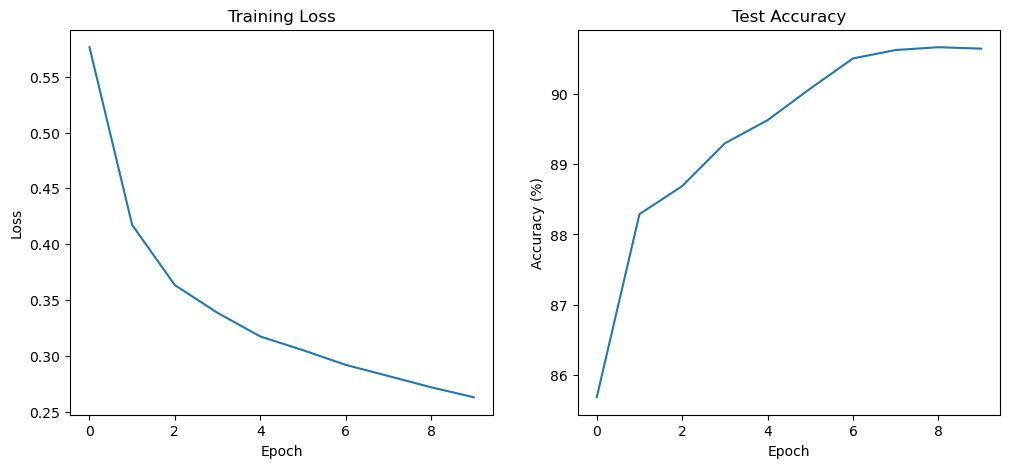

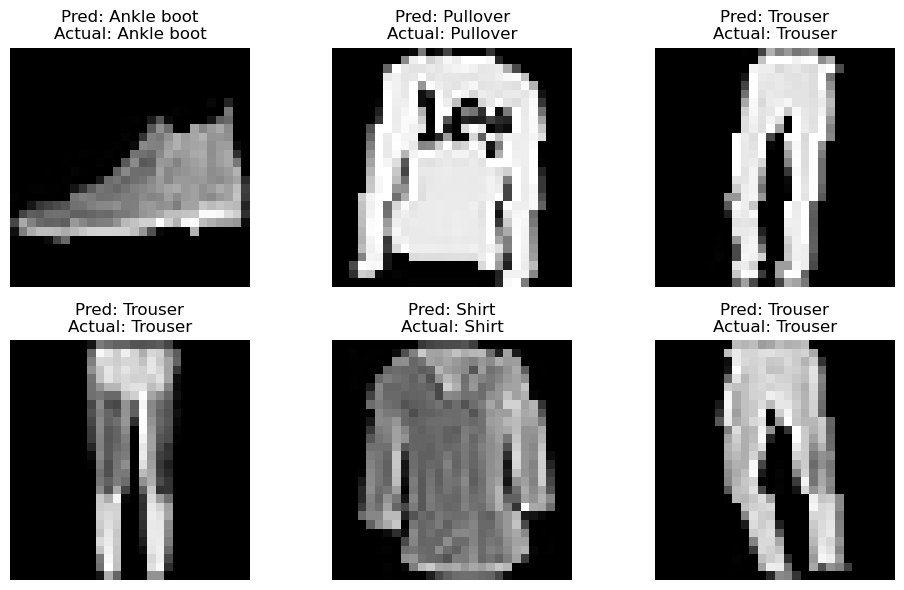

In [9]:
# Visualize results

# Plot loss and accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(test_accuracies)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.show()


# Show predictions
dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)
outputs = model(images)

_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Summary: Fashion MNIST Image Classifier
1. Load and explore the dataset 
Used the provided starter code with torchvision.datasets.FashionMNIST
Loaded both training and test datasets
Defined the 10 fashion categories

2. Preprocess the images 
Converted images to tensors using ToTensor()
Normalised pixel values using Normalize((0.5,), (0.5,))
Applied data augmentation using RandomRotation(10)

3. Build a CNN model 
Implemented a Convolutional Neural Network (SimpleCNN)
Model includes:
Convolutional layers for feature extraction
Max pooling layers for downsampling
Fully connected layers for classification
Output layer correctly predicts 10 classes

4. Train and evaluate the model 
Trained the model using:
Loss function: CrossEntropyLoss
Optimiser: Adam
Model performance improved steadily over 10 epochs:
Initial accuracy: 85.68%
Final accuracy: 90.65%
Loss consistently decreased from 0.5764 to 0.2629, indicating effective learning

5. Improve model performance 
Applied Batch Normalisation to stabilise and accelerate training
Used Dropout (0.5) to reduce overfitting
These techniques contributed to achieving accuracy above 90%

6. Visualise and analyse results 
Plotted:
Training loss over epochs (decreasing trend observed)
Test accuracy over epochs (steady improvement)
Displayed sample predictions vs actual labels
Observed that the model performs well across most categories

Conclusion
The model achieved a final test accuracy of 90.65%, demonstrating strong performance in classifying Fashion MNIST images. The steady decrease in loss and increase in accuracy across epochs indicate that the CNN model effectively learned meaningful features from the dataset.

Limitations and Future Improvements
While the model achieved strong performance, some classes with similar visual features (e.g. shirt vs coat) may still be misclassified.
The model is relatively simple and trained for only 10 epochs, which may limit its full potential.
Future improvements could include:
Adding more convolutional layers for deeper feature extraction
Using advanced data augmentation techniques
Tuning hyperparameters such as learning rate and batch size
Training for more epochs or using a learning rate scheduler